# Análise de Clusters de Perfis de Segurança de DMARDs

**Estudo:** Observacional, retrospectivo, com abordagem quantitativa  
**Fonte dos dados:** Sistema VigiMed (ANVISA) — base de dados secundária, anonimizada e de acesso público  
**Unidade analítica:** Medicamento (representado por variáveis agregadas)  

Este notebook implementa a metodologia descrita na seção 2 do artigo:
- Extração e padronização dos dados do VigiMed
- Construção das variáveis nas três dimensões analíticas: gravidade, complexidade clínica e distribuição sistêmica
- Padronização por escore Z
- Identificação de clusters via K-Means
- Validação por clusterização hierárquica aglomerativa (método de Ward)
- Caracterização dos perfis de segurança por cluster

## 1. Importação de bibliotecas

In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

## 2. Carregamento dos dados

Os dados são provenientes da camada `gold` do pipeline de dados, estruturada previamente com etapas de extração, tratamento e padronização. As tabelas utilizadas são:

- `fat_medicamentos`: fatos sobre os medicamentos notificados
- `fat_reacoes`: fatos sobre os eventos adversos notificados
- `dim_soc_llt`: dimensão de classificação MedDRA por sistema orgânico (SOC)

> **Reprodutibilidade:** o caminho `data/03_gold` é relativo à raiz do projeto. Ajuste conforme a estrutura local do repositório.

In [2]:
path = Path("../../data/03_gold")

fat_meds    = pd.read_parquet(path / "fat_medicamentos" / "fat_medicamentos.parquet")
fat_reacoes = pd.read_parquet(path / "fat_reacoes"      / "fat_reacoes.parquet")
dim_soc     = pd.read_parquet(path / "dim_soc_llt"      / "dim_soc_llt.parquet")

print(f"fat_medicamentos : {len(fat_meds):,} linhas | colunas: {fat_meds.columns.tolist()}")
print(f"fat_reacoes      : {len(fat_reacoes):,} linhas | colunas: {fat_reacoes.columns.tolist()}")
print(f"dim_soc_llt      : {len(dim_soc):,} linhas | colunas: {dim_soc.columns.tolist()}")

fat_medicamentos : 804,658 linhas | colunas: ['IDENTIFICACAO_NOTIFICACAO', 'RELACAO_MEDICAMENTO_EVENTO_CHAVE', 'RELACAO_MEDICAMENTO_EVENTO_VALOR', 'NOME_MEDICAMENTO_WHODRUG', 'PRINCIPIOS_ATIVOS_WHODRUG', 'ATC_CODE_LEVEL_4', 'DETENTOR_REGISTRO', 'DETENTOR_REGISTRO_SCORE', 'DETENTOR_REGISTRO_CHAVE', 'CONCENTRACAO_TIPO_CHAVE', 'CONCENTRACAO_TIPO_VALOR', 'CONCENTRACAO_VALOR', 'CONCENTRACAO_VALOR_NUMERADOR', 'CONCENTRACAO_VALOR_DENOMINADOR', 'COMPONENTE_SUSPEITO_CHAVE', 'COMPONENTE_SUSPEITO_VALOR', 'ACAO_ADOTADA_CHAVE', 'ACAO_ADOTADA_VALOR', 'PROB_ADIC_ABUSO', 'PROB_ADIC_ERRO_DE_MEDICACAO', 'PROB_ADIC_EXPOSICAO_OCUPACIONAL', 'PROB_ADIC_FALSIFICACAO', 'PROB_ADIC_LOTES_TESTADOS_E_DENTRO_DAS_ESPECIFICACOES', 'PROB_ADIC_LOTES_TESTADOS_E_FORA_DAS_ESPECIFICACOES', 'PROB_ADIC_MEDICAMENTO_TOMADO_FORA_DA_DATA_DE_VALIDADE', 'PROB_ADIC_MEDICAMENTO_TOMADO_PELO_PAI', 'PROB_ADIC_SUPERDOSE', 'PROB_ADIC_USO_INCORRETO', 'PROB_ADIC_USO_OFF_LABEL_USO_SEM_REGISTRO', 'INDICACAO_MEDDRA_REACAO_CHAVE', 'INDICACAO_

### 2.1 Verificação exploratória inicial

In [3]:
print("Valores únicos de RELACAO_MEDICAMENTO_EVENTO_VALOR:")
print(fat_meds["RELACAO_MEDICAMENTO_EVENTO_VALOR"].unique())

print("\nTop 20 princípios ativos notificados:")
print(fat_meds["PRINCIPIOS_ATIVOS_WHODRUG"].value_counts().head(20))

Valores únicos de RELACAO_MEDICAMENTO_EVENTO_VALOR:
<ArrowStringArray>
[                    'SUSPEITO',                 'CONCOMITANTE',
                 'DESCONHECIDO',                    'INTERAÇÃO',
 'MEDICAMENTO NÃO ADMINISTRADO']
Length: 5, dtype: str

Top 20 princípios ativos notificados:
PRINCIPIOS_ATIVOS_WHODRUG
DEXAMETHASONE                                 26400
COVID-19 VACCINE NRVV AD (CHADOX1 NCOV-19)    15048
PACLITAXEL                                    14842
PREDNISONE                                    11982
VANCOMYCIN                                    11781
HYDROCORTISONE                                11679
TOZINAMERAN                                    9745
POLYMYXIN B                                    9296
INFLIXIMABE                                    9281
COVID-19 VACCINE INACT (VERO) CZ02             6452
INFLIXIMAB                                     6336
CLONAZEPAM                                     6222
SECUKINUMAB                                    5386
MET

## 3. Critérios de elegibilidade e padronização dos medicamentos

Foram aplicados os seguintes critérios, conforme descritos na seção de Métodos:

1. **Inclusão apenas de medicamentos com papel de suspeito principal** (`RELACAO_MEDICAMENTO_EVENTO_VALOR = 'SUSPEITO'`)
2. **Presença simultânea de medicamento suspeito e evento adverso** — garantida pelo `INNER JOIN` entre `fat_meds` e `fat_reacoes`
3. **Identificação pelo princípio ativo** (Denominação Comum Internacional), com mapeamento para nomes padronizados em português
4. **Escopo restrito aos DMARDs** incluídos nos Protocolos Clínicos e Diretrizes Terapêuticas para artrite reumatoide (biológicos e sintéticos alvo-específicos)

Os medicamentos mapeados são: Rituximabe, Abatacepte, Etanercepte, Infliximabe, Adalimumabe, Certolizumabe Pegol, Golimumabe, Tocilizumabe, Tofacitinibe e Baricitinibe.

In [4]:
con = duckdb.connect()

query_elegibilidade = """
CREATE OR REPLACE TABLE base_cluster_limpa AS
WITH n_eventos_notif AS (
    -- Complexidade clínica: número de termos MedDRA por notificação
    SELECT
        IDENTIFICACAO_NOTIFICACAO,
        COUNT(REACAO_CHAVE) AS N_EVENTOS
    FROM fat_reacoes
    GROUP BY IDENTIFICACAO_NOTIFICACAO
)
SELECT DISTINCT
    f.IDENTIFICACAO_NOTIFICACAO,
    r.GRAVIDADE_RESULTADO_OBITO,
    r.GRAVIDADE_AMEACA_VIDA,
    r.GRAVIDADE_HOSPITALIZACAO,
    r.GRAVIDADE_INCAPACIDADE,
    ev.N_EVENTOS,
    s.SOC_NAME,
    -- Padronização do princípio ativo conforme DCI
    CASE
        WHEN f.PRINCIPIOS_ATIVOS_WHODRUG ILIKE '%rituximab%'    THEN 'Rituximabe'
        WHEN f.PRINCIPIOS_ATIVOS_WHODRUG ILIKE '%abatacept%'    THEN 'Abatacepte'
        WHEN f.PRINCIPIOS_ATIVOS_WHODRUG ILIKE '%etanercept%'   THEN 'Etanercepte'
        WHEN f.PRINCIPIOS_ATIVOS_WHODRUG ILIKE '%infliximab%'   THEN 'Infliximabe'
        WHEN f.PRINCIPIOS_ATIVOS_WHODRUG ILIKE '%adalimumab%'   THEN 'Adalimumabe'
        WHEN f.PRINCIPIOS_ATIVOS_WHODRUG ILIKE '%certolizumab%' THEN 'Certolizumabe Pegol'
        WHEN f.PRINCIPIOS_ATIVOS_WHODRUG ILIKE '%golimumab%'    THEN 'Golimumabe'
        WHEN f.PRINCIPIOS_ATIVOS_WHODRUG ILIKE '%tocilizumab%'  THEN 'Tocilizumabe'
        WHEN f.PRINCIPIOS_ATIVOS_WHODRUG ILIKE '%tofacitinib%'  THEN 'Tofacitinibe'
        WHEN f.PRINCIPIOS_ATIVOS_WHODRUG ILIKE '%baricitinib%'  THEN 'Baricitinibe'
    END AS MEDICAMENTO_PADRAO
FROM fat_meds f
-- Critério: presença simultânea de medicamento suspeito e evento adverso
INNER JOIN fat_reacoes r
    ON f.IDENTIFICACAO_NOTIFICACAO = r.IDENTIFICACAO_NOTIFICACAO
LEFT JOIN n_eventos_notif ev
    ON f.IDENTIFICACAO_NOTIFICACAO = ev.IDENTIFICACAO_NOTIFICACAO
LEFT JOIN dim_soc s
    ON r.REACAO_CHAVE = s.REACAO_CHAVE
-- Critério: apenas medicamentos suspeitos principais
WHERE f.RELACAO_MEDICAMENTO_EVENTO_VALOR = 'SUSPEITO'
  AND MEDICAMENTO_PADRAO IS NOT NULL  -- exclui medicamentos fora do escopo
"""

con.execute(query_elegibilidade)
df_limpo = con.table("base_cluster_limpa").df()

print("Notificações por medicamento após aplicação dos critérios de elegibilidade:")
print(df_limpo["MEDICAMENTO_PADRAO"].value_counts())

Notificações por medicamento após aplicação dos critérios de elegibilidade:
MEDICAMENTO_PADRAO
Infliximabe            28508
Golimumabe              9023
Rituximabe              8653
Adalimumabe             4949
Certolizumabe Pegol     3673
Tocilizumabe            2012
Etanercepte             1069
Baricitinibe             418
Abatacepte               383
Tofacitinibe             205
Name: count, dtype: int64


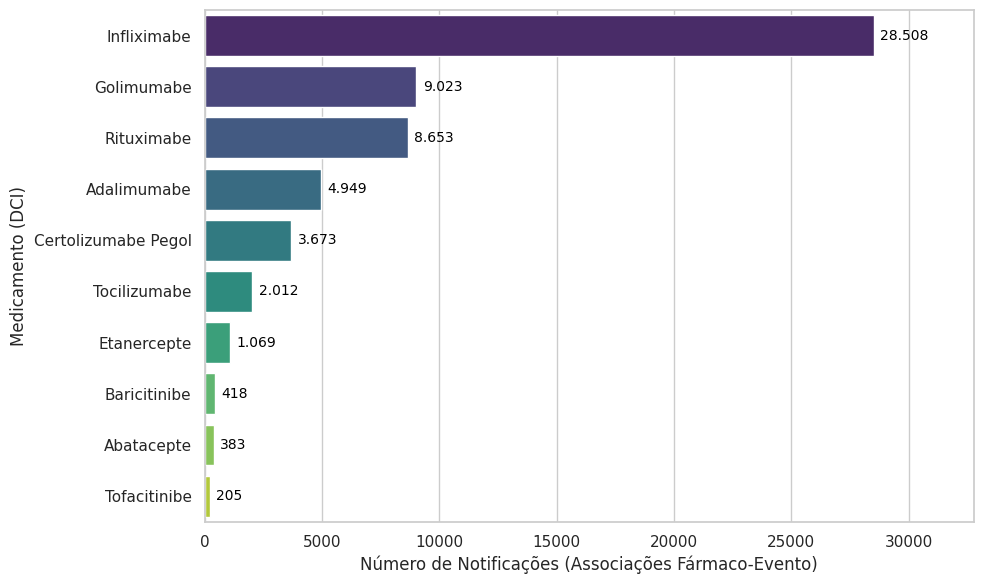

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Preparação dos dados
dados_freq = {
    'Medicamento': [
        'Infliximabe', 'Golimumabe', 'Rituximabe', 'Adalimumabe',
        'Certolizumabe Pegol', 'Tocilizumabe', 'Etanercepte',
        'Baricitinibe', 'Abatacepte', 'Tofacitinibe'
    ],
    'Notificações': [28508, 9023, 8653, 4949, 3673, 2012, 1069, 418, 383, 205]
}

df_figura = pd.DataFrame(dados_freq)

# 2. Configuração estética
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Criando o gráfico de barras
grafico = sns.barplot(
    x='Notificações',
    y='Medicamento',
    data=df_figura,
    palette='viridis',
    hue='Medicamento',
    legend=False
)

# --- AJUSTE CRÍTICO AQUI ---
# Aumentamos o limite do eixo X em 15% para dar espaço ao texto
limite_atual = df_figura['Notificações'].max()
plt.xlim(0, limite_atual * 1.15)
# ---------------------------

# 3. Ajustes de títulos e rótulos

plt.xlabel('Número de Notificações (Associações Fármaco-Evento)', fontsize=12)
plt.ylabel('Medicamento (DCI)', fontsize=12)

# Adicionando os valores nas pontas das barras com formatação brasileira
for i, v in enumerate(df_figura['Notificações']):
    valor_formatado = f'{v:,}'.replace(',', '.')
    grafico.text(v + (limite_atual * 0.01), i, valor_formatado, color='black', va='center', fontsize=10)

plt.tight_layout()
# plt.savefig('figura1_ajustada.png', dpi=300)
plt.show()

## 4. Construção da matriz de variáveis

As variáveis são organizadas nas três dimensões analíticas descritas na Tabela 1 do artigo:

| Dimensão | Variável | Operacionalização |
|---|---|---|
| Gravidade | Proporção de óbitos | Média de `GRAVIDADE_RESULTADO_OBITO` por fármaco |
| Gravidade | Proporção de hospitalização | Média de `GRAVIDADE_HOSPITALIZACAO` por fármaco |
| Gravidade | Proporção de ameaça à vida | Média de `GRAVIDADE_AMEACA_VIDA` por fármaco |
| Gravidade | Proporção de incapacidade | Média de `GRAVIDADE_INCAPACIDADE` por fármaco |
| Complexidade clínica | Média de eventos | Média de `N_EVENTOS` (termos MedDRA) por notificação |
| Distribuição sistêmica | Proporção por SOC | Proporção de eventos em cada sistema orgânico |

In [6]:
# Dimensão 3: distribuição sistêmica (proporção por SOC)
matriz_soc = pd.crosstab(df_limpo["MEDICAMENTO_PADRAO"], df_limpo["SOC_NAME"])
matriz_soc_pct = matriz_soc.div(matriz_soc.sum(axis=1), axis=0)

# Dimensões 1 e 2: gravidade e complexidade clínica
colunas_gravidade = [
    "GRAVIDADE_RESULTADO_OBITO",
    "GRAVIDADE_AMEACA_VIDA",
    "GRAVIDADE_HOSPITALIZACAO",
    "GRAVIDADE_INCAPACIDADE",
    "N_EVENTOS",
]
matriz_perfil = df_limpo.groupby("MEDICAMENTO_PADRAO")[colunas_gravidade].mean()

# Consolidação da matriz final (unidade analítica: medicamento)
df_cluster_final = pd.concat([matriz_soc_pct, matriz_perfil], axis=1).fillna(0)
df_cluster_final.index = df_cluster_final.index.str.strip().str.capitalize()
df_cluster_final = df_cluster_final.groupby(df_cluster_final.index).mean()

print(f"Matriz pronta: {df_cluster_final.shape[0]} medicamentos × {df_cluster_final.shape[1]} variáveis")
print("Medicamentos incluídos:", df_cluster_final.index.tolist())

Matriz pronta: 10 medicamentos × 32 variáveis
Medicamentos incluídos: ['Abatacepte', 'Adalimumabe', 'Baricitinibe', 'Certolizumabe pegol', 'Etanercepte', 'Golimumabe', 'Infliximabe', 'Rituximabe', 'Tocilizumabe', 'Tofacitinibe']


## 5. Padronização por escore Z

Previamente à análise, as variáveis foram padronizadas por escore Z — subtraindo a média e dividindo pelo desvio padrão — garantindo comparabilidade entre variáveis em diferentes escalas.

In [7]:
scaler = StandardScaler()  # z = (x - média) / desvio padrão

df_scaled = pd.DataFrame(
    scaler.fit_transform(df_cluster_final),
    index=df_cluster_final.index,
    columns=df_cluster_final.columns,
)

print("Verificação pós-padronização (média ≈ 0, desvio padrão ≈ 1):")
print(df_scaled.describe().loc[["mean", "std"]].round(4))

Verificação pós-padronização (média ≈ 0, desvio padrão ≈ 1):
      Circunstâncias sociais  Distúrbios cardíacos  \
mean                 -0.0000                0.0000   
std                   1.0541                1.0541   

      Distúrbios congênitos, de família e genéticos  \
mean                                         0.0000   
std                                          1.0541   

      Distúrbios do ouvido e do labirinto  Distúrbios do sistema imunitário  \
mean                               0.0000                           -0.0000   
std                                1.0541                            1.0541   

      Distúrbios do sistema nervoso  \
mean                         0.0000   
std                          1.0541   

      Distúrbios do sistema reprodutor e da mama  \
mean                                      0.0000   
std                                       1.0541   

      Distúrbios dos sistemas hematológico e linfático  \
mean                                   

## 6. Definição do número ótimo de clusters

O número ótimo de clusters foi definido com base em dois critérios quantitativos — método do cotovelo e coeficiente de silhouette — combinados com a interpretabilidade clínica dos agrupamentos resultantes.

In [8]:
K_range = range(2, 9)
distortions    = []
silhouette_avg = []

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(df_scaled)
    distortions.append(model.inertia_)
    silhouette_avg.append(silhouette_score(df_scaled, model.labels_))

df_validacao = pd.DataFrame(
    {"k": list(K_range), "Inércia (WCSS)": distortions, "Coef. Silhouette": silhouette_avg}
).set_index("k")
print(df_validacao.round(4))

   Inércia (WCSS)  Coef. Silhouette
k                                  
2        237.5338            0.2051
3        194.6849            0.1550
4        140.5966            0.0969
5        108.7673            0.0779
6         76.1813            0.0907
7         48.0669            0.0810
8         31.1076            0.0377


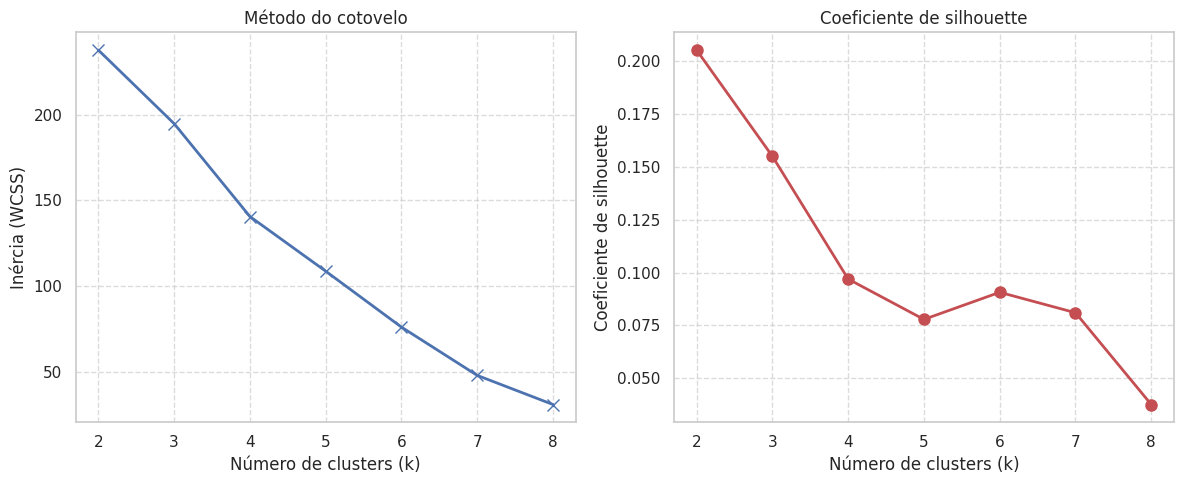

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(list(K_range), distortions, "bx-", linewidth=2, markersize=8)
axes[0].set_xlabel("Número de clusters (k)")
axes[0].set_ylabel("Inércia (WCSS)")
axes[0].set_title("Método do cotovelo")
axes[0].grid(True, linestyle="--", alpha=0.7)

axes[1].plot(list(K_range), silhouette_avg, "ro-", linewidth=2, markersize=8)
axes[1].set_xlabel("Número de clusters (k)")
axes[1].set_ylabel("Coeficiente de silhouette")
axes[1].set_title("Coeficiente de silhouette")
axes[1].grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.savefig("figura_validacao_clusters.png", dpi=300)
plt.show()

## 7. Clusterização K-Means

Com base nos critérios de validação e na interpretabilidade clínica, foi adotado **k = 3** clusters. O algoritmo K-Means foi executado com `random_state=42` para garantir reprodutibilidade.

In [10]:
K_OTIMO = 3  # definido pelos critérios do cotovelo, silhouette e interpretabilidade clínica

kmeans = KMeans(n_clusters=K_OTIMO, random_state=42, n_init=10)
clusters_km = kmeans.fit_predict(df_scaled)

df_resultados = df_cluster_final.copy()
df_resultados["Cluster"] = clusters_km + 1  # rótulos de 1 a k

print("Composição dos clusters (K-Means):")
for i in range(1, K_OTIMO + 1):
    meds = df_resultados[df_resultados["Cluster"] == i].index.tolist()
    print(f"  Cluster {i}: {', '.join(meds)}")

Composição dos clusters (K-Means):
  Cluster 1: Abatacepte, Adalimumabe, Baricitinibe, Certolizumabe pegol, Etanercepte, Golimumabe, Infliximabe, Tocilizumabe
  Cluster 2: Rituximabe
  Cluster 3: Tofacitinibe


## 8. Validação: clusterização hierárquica aglomerativa (método de Ward)

Como estratégia de validação, foi aplicada clusterização hierárquica aglomerativa com o método de Ward. A consistência entre os dois métodos é interpretada como indicativa de estabilidade dos agrupamentos.

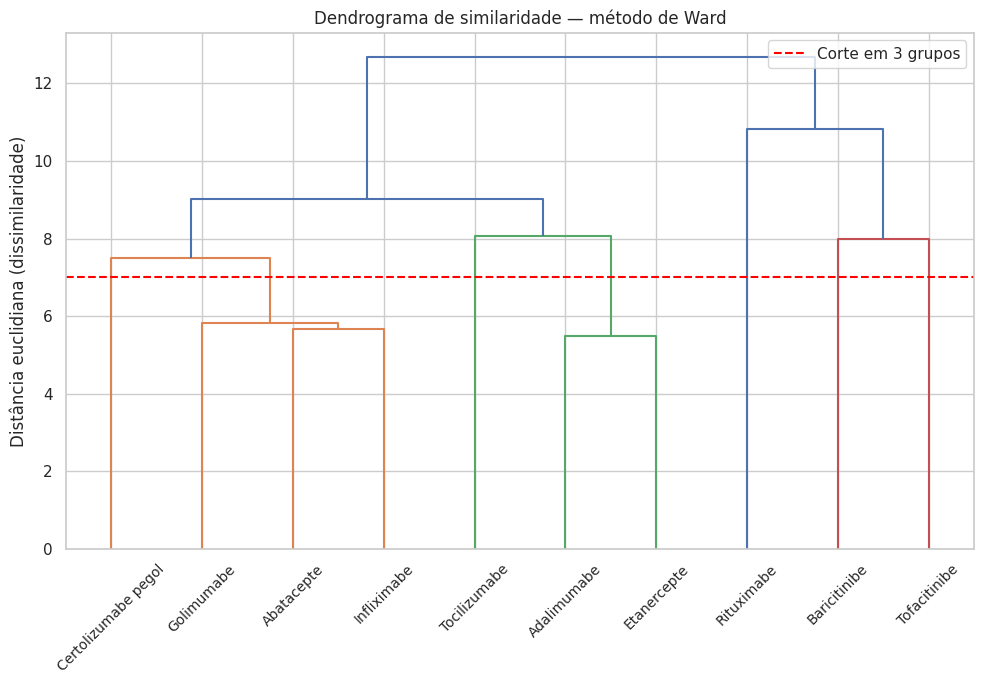

In [11]:
Z = linkage(df_scaled, method="ward")

plt.figure(figsize=(10, 7))
dendrogram(Z, labels=df_scaled.index.tolist(), leaf_rotation=45, leaf_font_size=10)
plt.title("Dendrograma de similaridade — método de Ward")
plt.ylabel("Distância euclidiana (dissimilaridade)")
plt.axhline(y=7, color="red", linestyle="--", label="Corte em 3 grupos")
plt.legend()
plt.tight_layout()
plt.savefig("figura_dendrograma_ward.png", dpi=300)
plt.show()

## 9. Caracterização dos perfis de segurança por cluster

Após a definição dos clusters, foram calculadas as médias das variáveis de gravidade e complexidade clínica em cada grupo, conforme descrito na seção de Métodos.

In [12]:
colunas_perfil = [
    "GRAVIDADE_RESULTADO_OBITO",
    "GRAVIDADE_HOSPITALIZACAO",
    "GRAVIDADE_AMEACA_VIDA",
    "GRAVIDADE_INCAPACIDADE",
    "N_EVENTOS",
]

perfil_resumo = df_resultados.groupby("Cluster")[colunas_perfil].mean()

# Formatação para leitura: gravidade em %, complexidade clínica como média absoluta
perfil_formatado = perfil_resumo.copy()
for col in colunas_perfil[:-1]:
    perfil_formatado[col] = (perfil_formatado[col] * 100).round(2).astype(str) + "%"
perfil_formatado["N_EVENTOS"] = perfil_formatado["N_EVENTOS"].round(2)

perfil_formatado.columns = [
    "Óbito (%)", "Hospitalização (%)", "Ameaça à vida (%)", "Incapacidade (%)", "Média de eventos"
]

print("Caracterização clínica dos clusters — médias das variáveis por grupo:")
print(perfil_formatado)

Caracterização clínica dos clusters — médias das variáveis por grupo:
        Óbito (%) Hospitalização (%) Ameaça à vida (%) Incapacidade (%)  \
Cluster                                                                   
1           3.38%             10.98%             0.58%            1.07%   
2           1.03%             10.63%             2.95%            0.43%   
3           5.85%             15.61%             2.93%             0.0%   

         Média de eventos  
Cluster                    
1                    6.62  
2                    3.86  
3                    4.18  


In [13]:
import pandas, numpy, sklearn, scipy, matplotlib, duckdb

print(pandas.__version__)
print(numpy.__version__)
print(sklearn.__version__)
print(scipy.__version__)
print(matplotlib.__version__)
print(duckdb.__version__)

3.0.0
2.4.2
1.8.0
1.17.0
3.10.8
1.4.4
